# Spotify Technical Analysis (2018-2025)
This notebook demonstrates the synthesis and analysis of raw Spotify streaming data.

### Steps Covered:
1. **Environment Setup & Configuration**
2. **Data Ingestion & Cleaning**
3. **Feature Engineering (Genres, Languages, Sessions)**
4. **Visualization & Pattern Recognition**
5. **Summary Reporting**

## 1. Environment Setup & Configuration

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import json
import os
import re
import numpy as np

# Configuration
DATA_DIR = '/Users/nidhi/Developer/Spotify Extended Streaming History'
OUTPUT_DIR = '/Users/nidhi/Developer/Spotify_Final_Output'
IMG_DIR = os.path.join(OUTPUT_DIR, 'images')

# Set visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Data Ingestion & Cleaning
Merging all JSON files into a single DataFrame and cleaning timestamps.

In [3]:
print('>>> Loading Data...')
files = glob.glob(os.path.join(DATA_DIR, 'Streaming_History_Audio_*.json'))
all_data = []
for f in files:
    with open(f, 'r') as file:
        all_data.extend(json.load(file))

df = pd.DataFrame(all_data)
df['ts'] = pd.to_datetime(df['ts'])
df['minutes_played'] = df['ms_played'] / 60000
df['year'] = df['ts'].dt.year
df['month'] = df['ts'].dt.month
df['hour'] = df['ts'].dt.hour
df = df[df['master_metadata_album_artist_name'].notna()]
df = df.sort_values('ts')
df.head()

>>> Loading Data...


,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,minutes_played,year,month,hour
105652,2018-04-10 15:07:29+00:00,"Android-tablet OS 5.1.1 API 22 (Sony, SM-T535)",3731,US,107.181.168.96,DNA,BTS,Love Yourself 承 'Her',spotify:track:5SE57ljOIUJ1ybL9U6CuBH,None,...,unexpected-exit-while-paused,False,False,False,NaN,False,0.062183,2018,4,15
105653,2018-04-10 15:50:02+00:00,"Android-tablet OS 5.1.1 API 22 (Sony, SM-T535)",561,US,107.181.168.96,Blood Sweat & Tears,BTS,Wings,spotify:track:5RGf8qn1TBWVplLyyKUsuV,None,...,fwdbtn,False,False,False,NaN,False,0.009350,2018,4,15
105654,2018-04-10 15:50:03+00:00,"Android-tablet OS 5.1.1 API 22 (Sony, SM-T535)",400,US,107.181.168.96,DNA,BTS,Love Yourself 承 'Her',spotify:track:5SE57ljOIUJ1ybL9U6CuBH,None,...,fwdbtn,False,False,False,NaN,False,0.006667,2018,4,15
105655,2018-04-10 15:50:04+00:00,"Android-tablet OS 5.1.1 API 22 (Sony, SM-T535)",0,US,107.181.168.96,Go Go,BTS,Love Yourself 承 'Her',spotify:track:5nq1uTNIR1cBR72T87viS0,None,...,fwdbtn,False,False,False,NaN,False,0.000000,2018,4,15
105656,2018-04-10 15:50:04+00:00,"Android-tablet OS 5.1.1 API 22 (Sony, SM-T535)",0,US,107.181.168.96,Best Of Me - Japanese ver.,BTS,FACE YOURSELF,spotify:track:6yGKx4J9UdMp7tcaGXWzDj,None,...,fwdbtn,False,False,False,NaN,False,0.000000,2018,4,15


## 3. Feature Engineering
Adding Genre and Language information and identifying 'Binge Sessions'.

In [4]:
GENRE_MAP = {'BTS': 'K-Pop', 'GOT7': 'K-Pop', 'Pritam': 'Bollywood', 'Umer Anjum': 'DHH', 'Taylor Swift': 'Western Pop'}
LANG_MAP = {'BTS': 'Korean', 'Pritam': 'Hindi', 'Young Stunners': 'Urdu'}

def detect_language(row):
    artist = row['master_metadata_album_artist_name']
    text = str(artist) + str(row['master_metadata_track_name'])
    if artist in LANG_MAP: return LANG_MAP[artist]
    if re.search(r'[\uac00-\ud7af]', text): return 'Korean'
    if re.search(r'[\u0900-\u097f]', text): return 'Hindi'
    return 'Other/English'

df['language'] = df.apply(detect_language, axis=1)
df['primary_genre'] = df['master_metadata_album_artist_name'].map(GENRE_MAP).fillna('Other')

# Session ID (gap > 15 mins starts a new session)
df['gap'] = (df['ts'] - df['ts'].shift(1)).dt.total_seconds() / 60
df['session_id'] = (df['gap'] > 15).cumsum()
print('Feature Engineering Complete!')

Feature Engineering Complete!


## 4. Visualizing Top Artists

/var/folders/jt/x4440rcn18v6z2bfhqbq5s9m0000gq/T/ipykernel_23295/3674241190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')


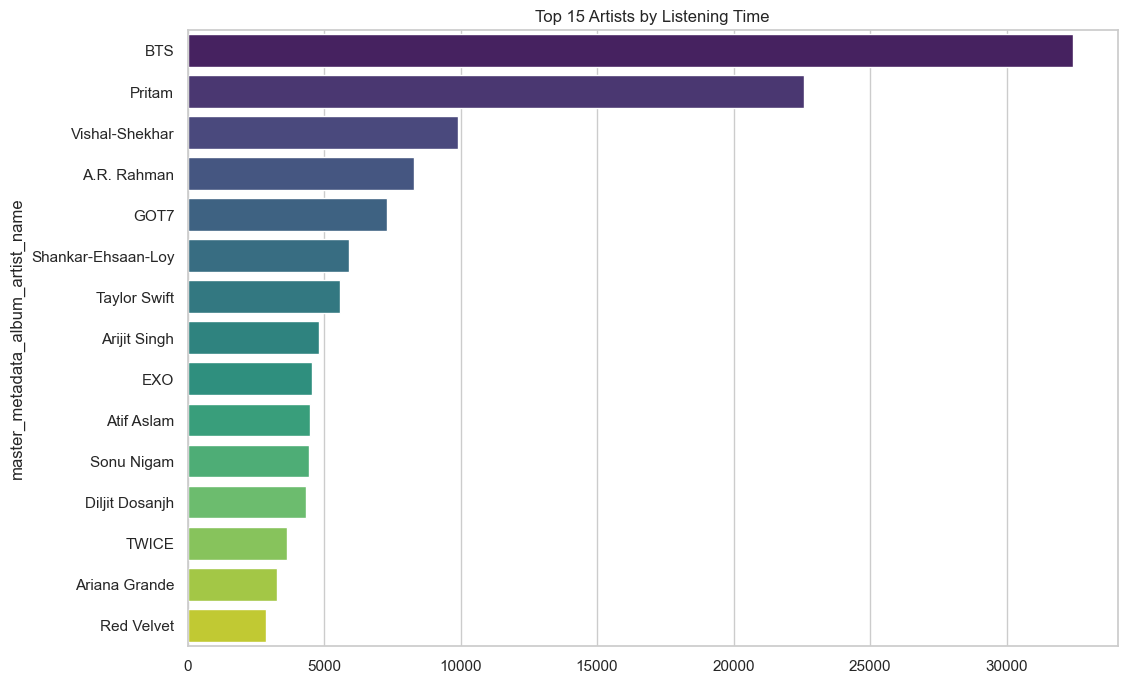

In [5]:
top_artists = df.groupby('master_metadata_album_artist_name')['minutes_played'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')
plt.title('Top 15 Artists by Listening Time')
plt.show()

## 5. The Genre Clock
Analyzing which hours of the day you prefer certain genres.

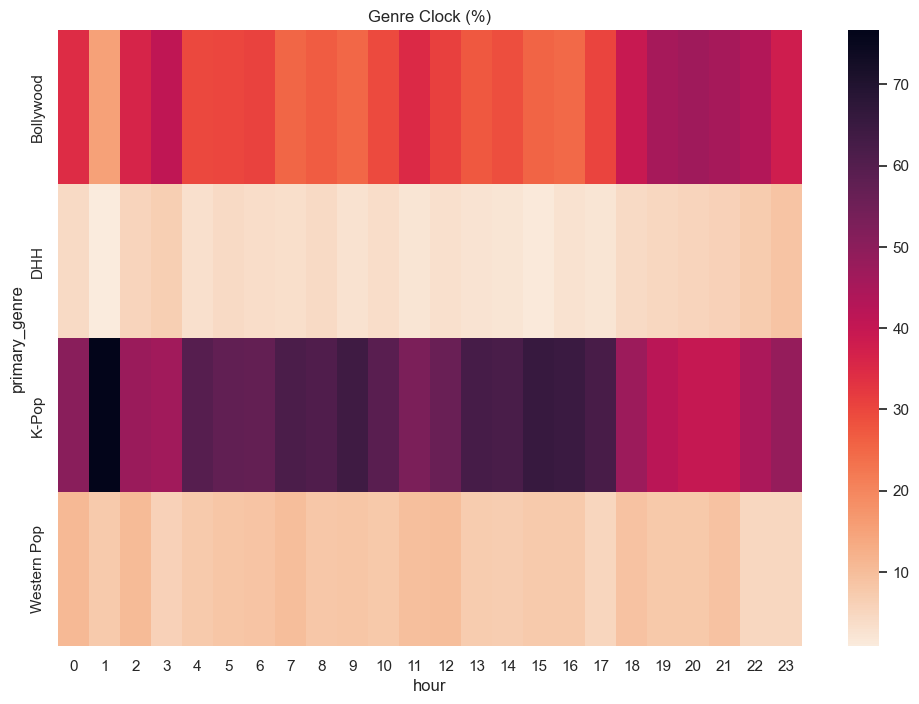

In [6]:
subset = df[df['primary_genre'] != 'Other']
pivot = subset.groupby(['hour', 'primary_genre'])['minutes_played'].sum().unstack().fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
sns.heatmap(pivot_pct.T, cmap='rocket_r')
plt.title('Genre Clock (%)')
plt.show()

## 6. Language Distribution

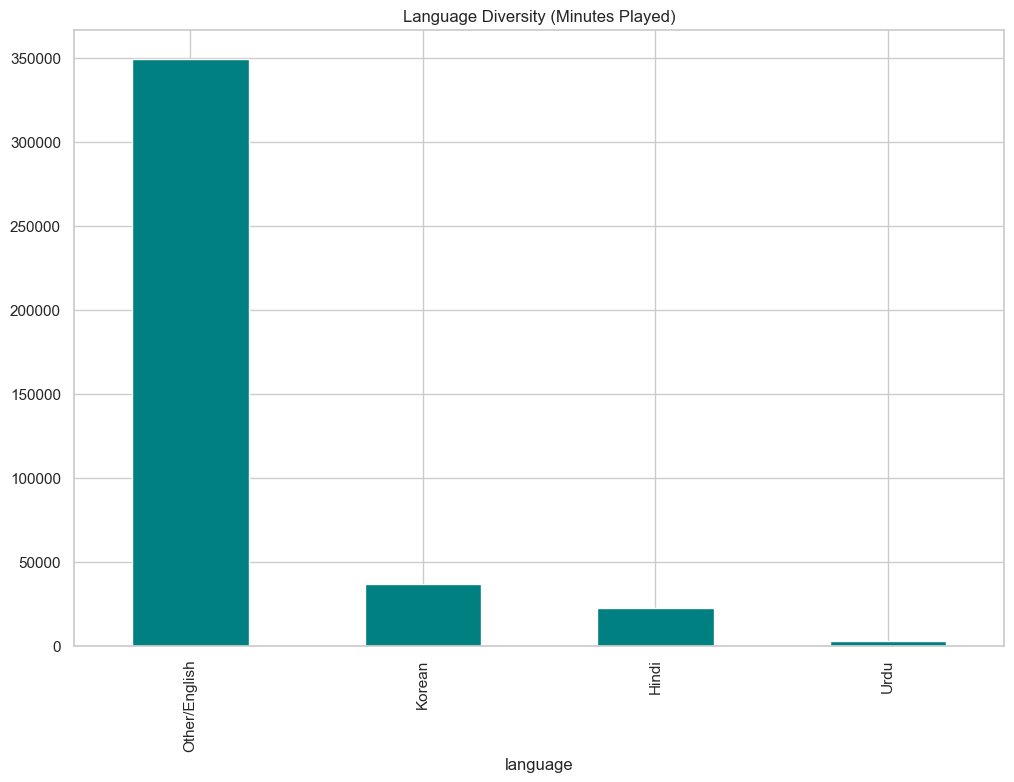

In [7]:
lang_counts = df.groupby('language')['minutes_played'].sum().sort_values(ascending=False)
lang_counts.plot(kind='bar', color='teal')
plt.title('Language Diversity (Minutes Played)')
plt.show()

## 7. Binge Session Analysis

In [14]:
session_stats = df.groupby('session_id').agg(duration_hours=('ts', lambda x: (x.max() - x.min()).total_seconds() / 3600), tracks=('ts', 'count'))
print('Your 5 Longest Marathons (Hours):')
print(session_stats.sort_values('duration_hours', ascending=False).head(5))
# 1. Calculate language statistics
    lang_stats = df.groupby('language')['minutes_played'].sum().sort_values(ascending=False).reset_index()
    
# 2. Rename columns for clarity
    lang_stats.columns = ['Language', 'Minutes Listened']
    
# 3. Add a percentage column for extra insight
    total_mins = lang_stats['Minutes Listened'].sum()
    lang_stats['Percentage (%)'] = (lang_stats['Minutes Listened'] / total_mins) * 100

   print("--- Language Distribution Table ---")display(lang_stats.style.format({'Minutes Listened': '{:,.2f}','Percentage (%)': '{:.2f}%'}).hide(axis='index'))

IndentationError: unindent does not match any outer indentation level (<string>, line 11)